In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [4]:
X = train.iloc[:, 1:].values
y = train.iloc[:,0].values

test = test.iloc[:,:].values

In [5]:
np.unique(np.isnan(X))

array([False])

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [7]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)
sc_test = sc_X.transform(test)

In [8]:
from sklearn.svm import SVC
print('SVM Classifier with gamma = 0.1; Kernel = Polynomial')
classifier = SVC(gamma=0.1, kernel='poly', random_state = 0)
classifier.fit(X_train,y_train)

SVM Classifier with gamma = 0.1; Kernel = Polynomial


,C,1.0
,kernel,'poly'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
y_pred = classifier.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score,confusion_matrix
model_acc = classifier.score(X_test, y_test)
test_acc = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test,y_pred)

In [11]:
print('\nSVM Trained Classifier Accuracy: ', model_acc)
print('\nPredicted Values: ',y_pred)
print('\nAccuracy of Classifier on Validation Images: ',test_acc)
print('\nConfusion Matrix: \n',conf_mat)


SVM Trained Classifier Accuracy:  0.974

Predicted Values:  [3 6 9 ... 4 0 5]

Accuracy of Classifier on Validation Images:  0.974

Confusion Matrix: 
 [[ 998    0    4    1    3    1    5    0    3    0]
 [   0 1180    5    1    0    0    0    1    2    1]
 [   4    0 1049    4    2    0    1    4   12    1]
 [   1    1    6 1022    1   14    0    5   14    6]
 [   1    3    4    0 1007    1    3    0    2   13]
 [   0    0    2    3    2  905    7    0    7    4]
 [   2    0    1    0    2    6 1031    0    2    0]
 [   3    5    7    1    7    1    0 1096    0    9]
 [   3    1    3    7    1    7    3    0  967    3]
 [   4    1    5    2   13    2    0   11    6  972]]


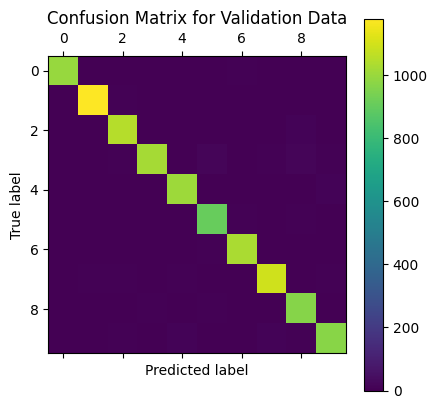

In [12]:
plt.matshow(conf_mat)
plt.title('Confusion Matrix for Validation Data')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [13]:
result = classifier.predict(sc_test)

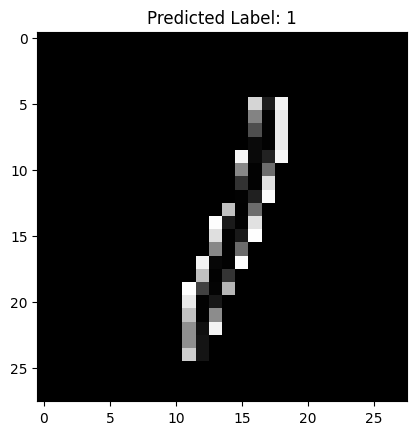

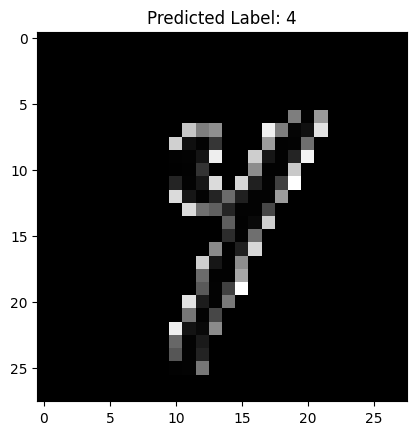

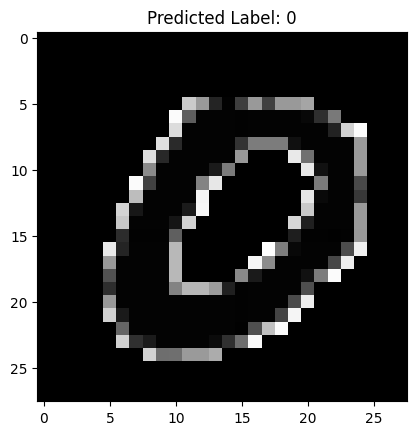

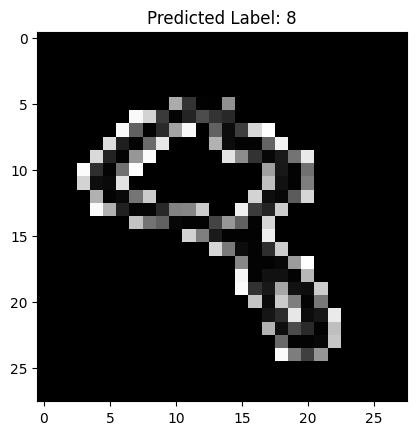

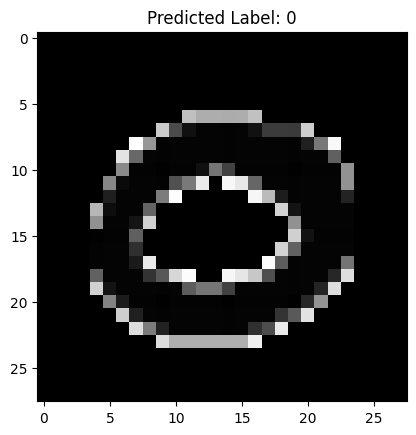

In [14]:
a = np.random.randint(1,400,5)
for i in a:
    two_d = (np.reshape(test[i], (28, 28)) * 255).astype(np.uint8)
    plt.title('Predicted Label: {0}'.format(result[i]))
    plt.imshow(two_d, interpolation='nearest',cmap='gray')
    plt.show()

In [15]:
submission = pd.Series(result,name="Label")

In [16]:
submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),submission],axis = 1)
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [17]:
submission.to_csv("final_submission_v1.csv",index=False)